# Task 4: Style-Conditioned Face-to-Sketch Generation Using a Conditional GAN
**Dataset:** FS2K Facial Sketch Synthesis Dataset (899 train / 159 val / 1,046 test pairs stratified by style 0, 1, 2)
**Architecture:** U-Net Generator with full skip connections at all levels + 70x70 PatchGAN Discriminator with categorical style embedding conditioning
**Loss Function:** $\mathcal{L}_{\text{cGAN}} = \mathcal{L}_{\text{adv}}(G, D) + \lambda_{\text{L1}} \mathcal{L}_{\text{L1}}(G)$
**Optimization:** 15-Trial Optuna Study tuning $\text{lr}_g, \text{lr}_d, \lambda_{\text{L1}}$, base channels, emb dim, and dropout rate.

### Step 1: Environment Diagnostics & GPU Verification

In [1]:
import torch
import os
import sys
import subprocess

print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Device: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / (1024**3):.2f} GB")
else:
    print("WARNING: Running on CPU. Switch to GPU runtime for reasonable training speeds!")

PyTorch Version: 2.11.0+cu128
CUDA Available: True
GPU Device: Tesla T4
VRAM: 14.56 GB


### Step 2: Mount Google Drive & Clone/Pull GitHub Repository

In [2]:
import os
import sys
import subprocess

# Mount Drive for data and checkpoint persistence
try:
    from google.colab import drive
    drive.mount('/content/drive')
except Exception:
    print("Google Drive mounting skipped (not running in Colab).")

REPO_DIR = '/content/genai-restoration-studio'
PROJECT_DIR = '/content/drive/MyDrive/GenAI-A1'

# Clone or pull repository
if not os.path.exists(REPO_DIR):
    print(f"Cloning repo into {REPO_DIR}...")
    subprocess.run(["git", "clone", "https://github.com/UsmanBari/genai-restoration-studio.git", REPO_DIR], check=True)
else:
    print(f"Pulling latest main into {REPO_DIR}...")
    subprocess.run(["git", "-C", REPO_DIR, "pull", "origin", "main"], check=True)

if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

os.chdir(REPO_DIR)
print(f"Working directory: {os.getcwd()}")

# Install requirements
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "onnx", "onnxruntime", "optuna", "mlflow"], check=False)
print("[SUCCESS] Environment and repository ready.")

Mounted at /content/drive
Cloning repo into /content/genai-restoration-studio...
Working directory: /content/genai-restoration-studio
[SUCCESS] Environment and repository ready.


### Step 2.5: Safety Backup of Prior Valid Checkpoint (Protect Epoch 28 Weights)

In [3]:
import os
import shutil

src = '/content/drive/MyDrive/GenAI-A1/checkpoints/task4'
dst = '/content/drive/MyDrive/GenAI-A1/checkpoints/task4_run1_backup'

if os.path.isdir(src) and not os.path.exists(dst):
    shutil.copytree(src, dst)
    print(f"[BACKUP SUCCESS] Successfully backed up {src} to {dst}")
elif os.path.exists(dst):
    print(f"[BACKUP PRESENT] Backup directory already exists at {dst}")
else:
    print("[INFO] No existing task4 checkpoint directory found to backup yet.")

if os.path.exists(dst):
    print("Backup directory contents:", os.listdir(dst))


[BACKUP SUCCESS] Successfully backed up /content/drive/MyDrive/GenAI-A1/checkpoints/task4 to /content/drive/MyDrive/GenAI-A1/checkpoints/task4_run1_backup
Backup directory contents: ['samples', 'best_cgan_generator.pth', 'training_history.json', 'training_history.csv', 'optuna_best_params.json']


### Step 3: Fast Local NVMe Caching & Dataset Preparation (FS2K)

In [5]:
import shutil
import json
import os
import sys
import ast
import zipfile
import torch

REPO_DIR = '/content/genai-restoration-studio' if os.path.exists('/content/genai-restoration-studio') else os.getcwd()
PROJECT_DIR = '/content/drive/MyDrive/GenAI-A1'
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)
os.chdir(REPO_DIR)

# --- Session patch: data/fs2k.py uses List/Dict/Any without importing them ---
fs2k_path = os.path.join(REPO_DIR, 'data', 'fs2k.py')
_src = open(fs2k_path, encoding='utf-8').read()
if '# typing-fix' not in _src:
    _tree = ast.parse(_src)
    _first = next((n for n in _tree.body
                   if isinstance(n, (ast.Import, ast.ImportFrom))
                   and not (isinstance(n, ast.ImportFrom) and n.module == '__future__')), None)
    _lines = _src.splitlines()
    _lines.insert((_first.lineno - 1) if _first else 0,
                  'from typing import List, Dict, Any, Optional, Tuple, Union  # typing-fix')
    open(fs2k_path, 'w', encoding='utf-8').write('\n'.join(_lines) + '\n')
    print('Patched typing imports into data/fs2k.py')

# Drop half-imported modules left behind by the failed import
for _m in [k for k in sys.modules if k == 'data' or k.startswith('data.')]:
    del sys.modules[_m]

from data.fs2k import FS2KDataset, get_fs2k_dataloaders

LOCAL_DATA_DIR = '/content/local_data/FS2K'
os.makedirs(LOCAL_DATA_DIR, exist_ok=True)

# Candidate zip locations in Drive
drive_zip_candidates = [
    os.path.join(PROJECT_DIR, 'raw/FS2K.zip'),
    os.path.join(PROJECT_DIR, 'raw/FS2K/FS2K.zip'),
    os.path.join(PROJECT_DIR, 'FS2K.zip'),
    os.path.join(PROJECT_DIR, 'data/FS2K.zip')
]

drive_folder_candidates = [
    os.path.join(PROJECT_DIR, 'raw/FS2K/FS2K'),
    os.path.join(PROJECT_DIR, 'raw/FS2K'),
    os.path.join(PROJECT_DIR, 'data/FS2K')
]

# Check if already extracted locally
if not os.path.exists(os.path.join(LOCAL_DATA_DIR, 'photo')):
    zip_found = None
    for zc in drive_zip_candidates:
        if os.path.exists(zc):
            zip_found = zc
            break

    if zip_found:
        print(f"Extracting FS2K dataset from {zip_found} to {LOCAL_DATA_DIR}...")
        with zipfile.ZipFile(zip_found, 'r') as zf:
            zf.extractall('/content/local_data/')
        nested = '/content/local_data/FS2K/FS2K'
        if os.path.exists(nested):
            for item in os.listdir(nested):
                shutil.move(os.path.join(nested, item), os.path.join(LOCAL_DATA_DIR, item))
    else:
        folder_found = None
        for fc in drive_folder_candidates:
            if os.path.exists(os.path.join(fc, 'photo')):
                folder_found = fc
                break
        if folder_found:
            print(f"Copying FS2K folder from {folder_found} to local NVMe {LOCAL_DATA_DIR}...")
            for item in os.listdir(folder_found):
                s = os.path.join(folder_found, item)
                d = os.path.join(LOCAL_DATA_DIR, item)
                if os.path.isdir(s):
                    shutil.copytree(s, d, dirs_exist_ok=True)
                else:
                    shutil.copy2(s, d)
        else:
            print("Using direct FS2K root resolution from manifests.")

# Manifest directory resolution: Drive first (authentic manifests)
manifest_candidates = [
    os.path.join(PROJECT_DIR, 'manifests'),
    os.path.join(PROJECT_DIR, 'configs/manifests'),
    os.path.join(REPO_DIR, 'configs/manifests'),
    os.path.join(REPO_DIR, 'manifests')
]
MANIFEST_DIR = None
for mc in manifest_candidates:
    if os.path.exists(os.path.join(mc, 'fs2k_train_manifest.json')):
        MANIFEST_DIR = mc
        break

if MANIFEST_DIR is None:
    raise FileNotFoundError("FS2K train manifest not found in Drive or repo!")

print(f"Manifest Directory Used: {MANIFEST_DIR}")

# Load and verify authentic manifest counts and style distribution
from collections import Counter
with open(os.path.join(MANIFEST_DIR, 'fs2k_train_manifest.json'), 'r', encoding='utf-8') as f:
    train_data = json.load(f)
with open(os.path.join(MANIFEST_DIR, 'fs2k_val_manifest.json'), 'r', encoding='utf-8') as f:
    val_data = json.load(f)
with open(os.path.join(MANIFEST_DIR, 'fs2k_test_manifest.json'), 'r', encoding='utf-8') as f:
    test_data = json.load(f)

train_styles = Counter(x['style'] for x in train_data)
val_styles = Counter(x['style'] for x in val_data)
test_styles = Counter(x['style'] for x in test_data)

print(f"Train Pairs: {len(train_data)} | Style Distribution: {dict(train_styles)}")
print(f"Val Pairs:   {len(val_data)} | Style Distribution: {dict(val_styles)}")
print(f"Test Pairs:  {len(test_data)} | Style Distribution: {dict(test_styles)}")

# Strict assertions enforcing authentic FS2K splits
assert len(train_data) == 898, f"Expected 898 train pairs, got {len(train_data)}"
assert len(val_data) == 160, f"Expected 160 val pairs, got {len(val_data)}"
assert len(test_data) == 1046, f"Expected 1046 test pairs, got {len(test_data)}"
assert dict(train_styles) == {0: 303, 1: 297, 2: 298}, f"Train style mismatch: {dict(train_styles)}"
assert dict(val_styles) == {0: 54, 1: 53, 2: 53}, f"Val style mismatch: {dict(val_styles)}"
assert dict(test_styles) == {0: 619, 1: 381, 2: 46}, f"Test style mismatch: {dict(test_styles)}"
print("✅ Authentic FS2K dataset split verified: 898 train / 160 val / 1,046 test.")

# Build DataLoaders
train_loader, val_loader, test_loader = get_fs2k_dataloaders(
    manifest_dir=MANIFEST_DIR,
    fs2k_root=LOCAL_DATA_DIR,
    batch_size=16,
    num_workers=0
)

print(f"Train batches: {len(train_loader)} ({len(train_loader.dataset)} pairs)")
print(f"Val batches:   {len(val_loader)} ({len(val_loader.dataset)} pairs)")
print(f"Test batches:  {len(test_loader)} ({len(test_loader.dataset)} pairs)")

# Pre-flight verification across all 2,104 pairs via the dataset's own resolver
print("\nRunning pre-flight verification across all 2,104 photo/sketch pairs...")

for name, ld in [('train', train_loader), ('val', val_loader), ('test', test_loader)]:
    ds = ld.dataset
    load_errors = []
    flat_samples = []

    for idx in range(len(ds)):
        item = ds.items[idx]
        p_path, s_path = ds._resolve_paths(item)
        if not os.path.exists(p_path) or not os.path.exists(s_path):
            load_errors.append((idx, item.get('image_name', ''), p_path, s_path))
            continue
        try:
            s = ds[idx]
            vals = s.values() if isinstance(s, dict) else s
            ts = [v for v in vals if torch.is_tensor(v) and v.dim() == 3]
            if any(float(t.float().std()) < 1e-3 for t in ts):
                flat_samples.append(idx)
        except Exception as e:
            load_errors.append((idx, item.get('image_name', ''), str(e)))

    print(f"[{name.upper()}] {len(ds)} samples | Missing/Load Errors: {len(load_errors)} | Flat/Placeholder Images: {len(flat_samples)}")
    if load_errors:
        print(f"  First 5 load errors in {name}: {load_errors[:5]}")
    assert len(load_errors) == 0, f"Found {len(load_errors)} load errors in {name} split!"
    assert len(flat_samples) == 0, f"Found {len(flat_samples)} flat/placeholder images in {name} split!"

print("\n✅ Pre-flight verification PASSED: all 2,104 photo/sketch pairs resolved, 0 load errors, 0 flat images.")

Patched typing imports into data/fs2k.py
Extracting FS2K dataset from /content/drive/MyDrive/GenAI-A1/raw/FS2K/FS2K.zip to /content/local_data/FS2K...
Manifest Directory Used: /content/drive/MyDrive/GenAI-A1/manifests
Train Pairs: 898 | Style Distribution: {0: 303, 1: 297, 2: 298}
Val Pairs:   160 | Style Distribution: {0: 54, 1: 53, 2: 53}
Test Pairs:  1046 | Style Distribution: {1: 381, 0: 619, 2: 46}
✅ Authentic FS2K dataset split verified: 898 train / 160 val / 1,046 test.
Train batches: 57 (898 pairs)
Val batches:   10 (160 pairs)
Test batches:  66 (1046 pairs)

Running pre-flight verification across all 2,104 photo/sketch pairs...
[TRAIN] 898 samples | Missing/Load Errors: 0 | Flat/Placeholder Images: 0
[VAL] 160 samples | Missing/Load Errors: 0 | Flat/Placeholder Images: 0
[TEST] 1046 samples | Missing/Load Errors: 0 | Flat/Placeholder Images: 0

✅ Pre-flight verification PASSED: all 2,104 photo/sketch pairs resolved, 0 load errors, 0 flat images.


### Step 4: Baseline Model Sanity Check (U-Net Generator & PatchGAN Discriminator)

In [6]:
from models.cgan import StyleConditionedUNetGenerator, ConditionalPatchGANDiscriminator
from training.losses_cgan import ConditionalGANLoss

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

dummy_g = StyleConditionedUNetGenerator().to(device)
dummy_d = ConditionalPatchGANDiscriminator().to(device)
criterion = ConditionalGANLoss(lambda_l1=100.0)

batch = next(iter(train_loader))
p = batch['photo'].to(device)
s = batch['sketch'].to(device)
st = batch['style'].to(device)

fake = dummy_g(p, st)
d_real = dummy_d(p, s, st)
d_fake = dummy_d(p, fake.detach(), st)

loss_d, m_d = criterion.discriminator_loss(d_real, d_fake)
loss_g, m_g = criterion.generator_loss(dummy_d(p, fake, st), fake, s)

print(f"Generator Output Shape:     {fake.shape} (Range: [{fake.min():.2f}, {fake.max():.2f}])")
print(f"Discriminator Patch Logits: {d_real.shape}")
print(f"Loss D: {loss_d.item():.4f} (Real Acc: {m_d['d_acc_real']*100:.1f}%, Fake Acc: {m_d['d_acc_fake']*100:.1f}%)")
print(f"Loss G: {loss_g.item():.4f} (Adv: {m_g['loss_g_adv']:.4f}, L1: {m_g['loss_g_l1']:.4f})")
print("[SUCCESS] Baseline cGAN sanity check passed.")

Using device: cuda
Generator Output Shape:     torch.Size([16, 3, 128, 128]) (Range: [-1.00, 1.00])
Discriminator Patch Logits: torch.Size([16, 1, 14, 14])
Loss D: 0.7074 (Real Acc: 34.8%, Fake Acc: 65.9%)
Loss G: 80.1410 (Adv: 0.7899, L1: 0.7935)
[SUCCESS] Baseline cGAN sanity check passed.


### Step 5: 15-Trial Optuna Hyperparameter Optimization Study

In [7]:
import os
import sys
import json
import torch

REPO_DIR = '/content/genai-restoration-studio' if os.path.exists('/content/genai-restoration-studio') else os.getcwd()
PROJECT_DIR = '/content/drive/MyDrive/GenAI-A1'
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)
os.chdir(REPO_DIR)

from training.optuna_cgan import run_optuna_cgan_study

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

study = run_optuna_cgan_study(
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    n_trials=15,
    epochs_per_trial=10,
    study_name="task4_cgan_fs2k_study"
)

best_params = study.best_params
print("\nWinning Optuna Hyperparameters:")
for k, v in best_params.items():
    print(f"  {k}: {v}")

# Persist best_params to both local repo and Google Drive immediately
local_optuna_path = os.path.join(REPO_DIR, 'checkpoints/task4/optuna_best_params.json')
drive_optuna_path = os.path.join(PROJECT_DIR, 'checkpoints/task4/optuna_best_params.json')

os.makedirs(os.path.dirname(local_optuna_path), exist_ok=True)
try:
    os.makedirs(os.path.dirname(drive_optuna_path), exist_ok=True)
except Exception:
    pass

with open(local_optuna_path, 'w', encoding='utf-8') as f:
    json.dump(best_params, f, indent=2)

try:
    with open(drive_optuna_path, 'w', encoding='utf-8') as f:
        json.dump(best_params, f, indent=2)
    print(f"[SUCCESS] Saved Optuna best parameters to Google Drive at {drive_optuna_path}")
except Exception as e:
    print(f"[WARNING] Could not save best_params to Drive: {e}")

[I 2026-09-28 16:25:43,384] A new study created in memory with name: task4_cgan_fs2k_study



[OPTUNA] Starting 15-trial study for Task 4 cGAN (10 epochs/trial)...


[I 2026-09-28 16:27:28,770] Trial 0 finished with value: 0.5743359633396231 and parameters: {'lr_g': 0.00048167602173743884, 'lr_d': 4.1506457068846955e-05, 'batch_size': 16, 'lambda_l1': 275.0, 'base_channels_g': 32, 'emb_dim': 16, 'dropout_rate': 0.2}. Best is trial 0 with value: 0.5743359633396231.
[I 2026-09-28 16:29:17,560] Trial 1 finished with value: 0.6010757195498334 and parameters: {'lr_g': 0.00014831617986795612, 'lr_d': 0.00015323432248336635, 'batch_size': 8, 'lambda_l1': 150.0, 'base_channels_g': 32, 'emb_dim': 32, 'dropout_rate': 0.0}. Best is trial 0 with value: 0.5743359633396231.
[I 2026-09-28 16:30:59,978] Trial 2 finished with value: 0.6252907879048288 and parameters: {'lr_g': 0.0003417502314006315, 'lr_d': 0.0001293985158143563, 'batch_size': 32, 'lambda_l1': 175.0, 'base_channels_g': 32, 'emb_dim': 64, 'dropout_rate': 0.0}. Best is trial 0 with value: 0.5743359633396231.
[I 2026-09-28 16:32:47,994] Trial 3 finished with value: 0.6343574447913184 and parameters: {'


[OPTUNA STUDY COMPLETE] Best Val Composite Score: 0.5435
Best Hyperparameters:
  - lr_g: 0.00035315750290239236
  - lr_d: 0.0001689665787554222
  - batch_size: 8
  - lambda_l1: 275.0
  - base_channels_g: 64
  - emb_dim: 64
  - dropout_rate: 0.0

Winning Optuna Hyperparameters:
  lr_g: 0.00035315750290239236
  lr_d: 0.0001689665787554222
  batch_size: 8
  lambda_l1: 275.0
  base_channels_g: 64
  emb_dim: 64
  dropout_rate: 0.0
[SUCCESS] Saved Optuna best parameters to Google Drive at /content/drive/MyDrive/GenAI-A1/checkpoints/task4/optuna_best_params.json


### Step 6: Full Schedule 40-Epoch Training of Optimal cGAN Model

In [8]:
import os
import sys
import json
import shutil
import torch
from torch.utils.data import DataLoader

REPO_DIR = '/content/genai-restoration-studio' if os.path.exists('/content/genai-restoration-studio') else os.getcwd()
PROJECT_DIR = '/content/drive/MyDrive/GenAI-A1'
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)
os.chdir(REPO_DIR)

from models.cgan import StyleConditionedUNetGenerator, ConditionalPatchGANDiscriminator
from training.trainer_cgan import train_cgan_full
from data.fs2k import get_fs2k_dataloaders

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Recover best_params if missing from memory
if 'best_params' not in globals() or not best_params:
    optuna_paths = [
        os.path.join(PROJECT_DIR, 'checkpoints/task4/optuna_best_params.json'),
        os.path.join(REPO_DIR, 'checkpoints/task4/optuna_best_params.json')
    ]
    loaded_params = None
    for op in optuna_paths:
        if os.path.exists(op):
            with open(op, 'r', encoding='utf-8') as f:
                loaded_params = json.load(f)
            print(f"[RECOVERY] Loaded Optuna parameters from {op}")
            break
    if loaded_params is None:
        print("[WARNING] No saved Optuna parameters found. Falling back to baseline configuration.")
        loaded_params = {
            'lr_g': 0.0004,
            'lr_d': 0.00008,
            'batch_size': 16,
            'lambda_l1': 100.0,
            'base_channels_g': 64,
            'emb_dim': 32,
            'dropout_rate': 0.5
        }
    best_params = loaded_params

# Ensure dataloaders exist
if 'train_loader' not in globals() or 'val_loader' not in globals():
    manifest_candidates = [
        os.path.join(PROJECT_DIR, 'manifests'),
        os.path.join(PROJECT_DIR, 'configs/manifests'),
        os.path.join(REPO_DIR, 'configs/manifests'),
        os.path.join(REPO_DIR, 'manifests')
    ]
    m_dir = next(mc for mc in manifest_candidates if os.path.exists(os.path.join(mc, 'fs2k_train_manifest.json')))
    local_data = '/content/local_data/FS2K' if os.path.exists('/content/local_data/FS2K') else os.path.join(PROJECT_DIR, 'raw/FS2K/FS2K')
    train_loader, val_loader, test_loader = get_fs2k_dataloaders(m_dir, local_data, batch_size=16, num_workers=0)

# Rebuild train_loader with optimal batch size from Optuna
opt_bs = int(best_params.get('batch_size', 16))
opt_train_loader = DataLoader(train_loader.dataset, batch_size=opt_bs, shuffle=True, num_workers=0)

# Instantiate models with optimal Optuna parameters
best_g = StyleConditionedUNetGenerator(
    in_channels=3,
    out_channels=3,
    num_styles=3,
    emb_dim=int(best_params.get('emb_dim', 32)),
    emb_channels=16,
    base_channels=int(best_params.get('base_channels_g', 64)),
    dropout_rate=float(best_params.get('dropout_rate', 0.5))
).to(device)

best_d = ConditionalPatchGANDiscriminator(
    in_channels=3,
    num_styles=3,
    emb_dim=int(best_params.get('emb_dim', 32)),
    emb_channels=16,
    base_channels=64
).to(device)

save_dir = os.path.join(REPO_DIR, 'checkpoints/task4')
drive_save_dir = os.path.join(PROJECT_DIR, 'checkpoints/task4')
os.makedirs(save_dir, exist_ok=True)
try:
    os.makedirs(drive_save_dir, exist_ok=True)
except Exception:
    pass

# Rebalancing: enforce 0.2x D/G learning rate ratio and D throttling
opt_lr_g = float(best_params.get('lr_g', 4e-4))
opt_lr_d = opt_lr_g * 0.2
print(f"Rebalanced Learning Rates: G={opt_lr_g:.2e}, D={opt_lr_d:.2e} (D/G ratio: {opt_lr_d/opt_lr_g:.2f})")

training_results = train_cgan_full(
    net_g=best_g,
    net_d=best_d,
    train_loader=opt_train_loader,
    val_loader=val_loader,
    device=device,
    save_dir=save_dir,
    drive_save_dir=drive_save_dir,
    epochs=40,
    lr_g=opt_lr_g,
    lr_d=opt_lr_d,
    lambda_l1=float(best_params.get('lambda_l1', 100.0)),
    d_update_freq=2,
    d_max_acc_throttle=0.85,
    patience=8,
    experiment_name="Task4_cGAN_FS2K_Full"
)

# Confirm checkpoint persistence to Drive
if os.path.exists(save_dir) and os.path.exists(drive_save_dir):
    for f in os.listdir(save_dir):
        s_path = os.path.join(save_dir, f)
        d_path = os.path.join(drive_save_dir, f)
        if os.path.isfile(s_path):
            shutil.copy2(s_path, d_path)
print(f"[SUCCESS] Checkpoint synchronized to Drive: {drive_save_dir}")

Using device: cuda
Rebalanced Learning Rates: G=3.53e-04, D=7.06e-05 (D/G ratio: 0.20)


2026/09/28 16:51:09 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/09/28 16:51:09 INFO mlflow.store.db.utils: Updating database tables
2026/09/28 16:51:11 INFO mlflow.tracking.fluent: Experiment with name 'Task4_cGAN_FS2K_Full' does not exist. Creating a new experiment.



=== Starting cGAN Training (40 epochs, lr_g=3.5e-04, lr_d=7.1e-05 [0.2x ratio], lambda_l1=275.0, d_freq=2, throttle=0.85) ===
Epoch [01/40] (12.5s) | D Real: 0.6918, Fake: 0.4910 (Acc: 70.0%, D_up: 42%) | G Adv: 1.0322, L1: 0.2678 | Val PSNR: 15.56dB SSIM: 0.4267 [BEST]
Epoch [02/40] (12.9s) | D Real: 0.5371, Fake: 0.3563 (Acc: 88.9%, D_up: 12%) | G Adv: 1.3045, L1: 0.2176 | Val PSNR: 16.21dB SSIM: 0.4782 [BEST]
Epoch [03/40] (14.5s) | D Real: 0.5050, Fake: 0.3486 (Acc: 91.4%, D_up: 4%) | G Adv: 1.3448, L1: 0.2093 | Val PSNR: 15.76dB SSIM: 0.4549 (no gain for 1/8 eps)
  >> [WARNING] Discriminator accuracy at 91.8% for 3 consecutive epochs! Throttling D updates.
Epoch [04/40] (13.7s) | D Real: 0.5212, Fake: 0.3290 (Acc: 91.8%, D_up: 1%) | G Adv: 1.3717, L1: 0.2016 | Val PSNR: 15.94dB SSIM: 0.4782 (no gain for 2/8 eps)
  >> [WARNING] Discriminator accuracy at 92.9% for 4 consecutive epochs! Throttling D updates.
Epoch [05/40] (11.9s) | D Real: 0.4846, Fake: 0.3717 (Acc: 92.9%, D_up: 3%)

In [9]:
import json
for name in ['task4_run1_backup', 'task4']:
    h = json.load(open(f'/content/drive/MyDrive/GenAI-A1/checkpoints/{name}/training_history.json'))
    h = h['history'] if isinstance(h, dict) and 'history' in h else h
    best = max(h, key=lambda e: e.get('val_ssim', 0) - e.get('val_l1', 0))
    print(name, {k: best[k] for k in ('epoch', 'val_psnr', 'val_ssim', 'val_l1') if k in best},
          'score =', round(best['val_l1'] + 1 - best['val_ssim'], 4))

task4_run1_backup {'epoch': 28, 'val_psnr': 16.841, 'val_ssim': 0.5387, 'val_l1': 0.088} score = 0.5493
task4 {'epoch': 21, 'val_psnr': 17.167, 'val_ssim': 0.5522, 'val_l1': 0.08534} score = 0.5331


### Step 7: Style-Stratified Evaluation on Test Split (Styles 0, 1, 2, Overall)

In [10]:
import os
import sys
import json
import shutil
import torch

REPO_DIR = '/content/genai-restoration-studio' if os.path.exists('/content/genai-restoration-studio') else os.getcwd()
PROJECT_DIR = '/content/drive/MyDrive/GenAI-A1'
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)
os.chdir(REPO_DIR)

from models.cgan import StyleConditionedUNetGenerator
from evaluation.benchmark_cgan import run_cgan_benchmark

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Resolve manifest and local data dirs
manifest_candidates = [
    os.path.join(PROJECT_DIR, 'manifests'),
    os.path.join(PROJECT_DIR, 'configs/manifests'),
    os.path.join(REPO_DIR, 'configs/manifests'),
    os.path.join(REPO_DIR, 'manifests')
]
MANIFEST_DIR = next(mc for mc in manifest_candidates if os.path.exists(os.path.join(mc, 'fs2k_test_manifest.json')))

LOCAL_DATA_DIR = '/content/local_data/FS2K'
if not os.path.exists(os.path.join(LOCAL_DATA_DIR, 'photo')):
    drive_folder_candidates = [
        os.path.join(PROJECT_DIR, 'raw/FS2K/FS2K'),
        os.path.join(PROJECT_DIR, 'raw/FS2K'),
        os.path.join(PROJECT_DIR, 'data/FS2K')
    ]
    for fc in drive_folder_candidates:
        if os.path.exists(os.path.join(fc, 'photo')):
            LOCAL_DATA_DIR = fc
            break

print(f"Manifest Dir:   {MANIFEST_DIR}")
print(f"FS2K Data Root: {LOCAL_DATA_DIR}")

# Find and strictly load checkpoint from Drive or local
ckpt_candidates = [
    os.path.join(PROJECT_DIR, 'checkpoints/task4/best_cgan_generator.pth'),
    os.path.join(REPO_DIR, 'checkpoints/task4/best_cgan_generator.pth'),
    os.path.join(PROJECT_DIR, 'checkpoints/task4/best_generator.pth'),
    os.path.join(REPO_DIR, 'checkpoints/task4/best_generator.pth')
]

target_ckpt = None
for cp in ckpt_candidates:
    if os.path.exists(cp):
        target_ckpt = cp
        break

if target_ckpt is None:
    raise FileNotFoundError(
        "FATAL: No Task 4 generator checkpoint found! "
        "Expected 'best_cgan_generator.pth' under Drive or local checkpoints directory. "
        "Run Step 6 to train or verify Drive mount."
    )

print(f"\n[CHECKPOINT FOUND] Loading checkpoint strictly from: {target_ckpt}")
ckpt = torch.load(target_ckpt, map_location=device)

# Load architecture parameters from optuna_best_params.json or directly from checkpoint dictionary
optuna_candidates = [
    os.path.join(PROJECT_DIR, 'checkpoints/task4/optuna_best_params.json'),
    os.path.join(REPO_DIR, 'checkpoints/task4/optuna_best_params.json')
]
eval_params = {}
for op in optuna_candidates:
    if os.path.exists(op):
        with open(op, 'r', encoding='utf-8') as f:
            eval_params = json.load(f)
        print(f"  Loaded architecture params from {op}")
        break

emb_dim = int(ckpt.get('emb_dim', eval_params.get('emb_dim', 32)) if isinstance(ckpt, dict) else eval_params.get('emb_dim', 32))
base_ch = int(ckpt.get('base_channels_g', eval_params.get('base_channels_g', 64)) if isinstance(ckpt, dict) else eval_params.get('base_channels_g', 64))
drop_rate = float(eval_params.get('dropout_rate', 0.2))

best_g = StyleConditionedUNetGenerator(
    in_channels=3,
    out_channels=3,
    num_styles=3,
    emb_dim=emb_dim,
    emb_channels=16,
    base_channels=base_ch,
    dropout_rate=drop_rate
).to(device)

state_dict = ckpt['generator_state_dict'] if isinstance(ckpt, dict) and 'generator_state_dict' in ckpt else ckpt
best_g.load_state_dict(state_dict, strict=True)
best_g.eval()

if isinstance(ckpt, dict):
    saved_ep = ckpt.get('epoch', 'N/A')
    saved_metrics = ckpt.get('val_metrics', {})
    print(f"  Loaded Generator Weights from Epoch {saved_ep} | Stored Val PSNR: {saved_metrics.get('psnr', 'N/A')} dB | SSIM: {saved_metrics.get('ssim', 'N/A')}")

# Run full test benchmark
out_dir = "artifacts/evaluation_task4"
benchmark_results = run_cgan_benchmark(
    generator=best_g,
    manifest_path=MANIFEST_DIR,
    fs2k_root=LOCAL_DATA_DIR,
    device=str(device),
    output_dir=out_dir,
    num_visualizations=12
)

# Sync evaluation artifacts to Drive
drive_art_dir = os.path.join(PROJECT_DIR, 'artifacts/evaluation_task4')
os.makedirs(drive_art_dir, exist_ok=True)
if os.path.exists(out_dir):
    for root, dirs, files in os.walk(out_dir):
        rel = os.path.relpath(root, out_dir)
        target_root = os.path.join(drive_art_dir, rel) if rel != '.' else drive_art_dir
        os.makedirs(target_root, exist_ok=True)
        for f in files:
            shutil.copy2(os.path.join(root, f), os.path.join(target_root, f))
print(f"[SUCCESS] Evaluation report and figures synchronized to Drive: {drive_art_dir}")

Using device: cuda
Manifest Dir:   /content/drive/MyDrive/GenAI-A1/manifests
FS2K Data Root: /content/local_data/FS2K

[CHECKPOINT FOUND] Loading checkpoint strictly from: /content/drive/MyDrive/GenAI-A1/checkpoints/task4/best_cgan_generator.pth
  Loaded architecture params from /content/drive/MyDrive/GenAI-A1/checkpoints/task4/optuna_best_params.json
  Loaded Generator Weights from Epoch 21 | Stored Val PSNR: 17.1674355294922 dB | SSIM: 0.5522210218201109
[BENCHMARK] Evaluating cGAN Generator on FS2K test split (1046 pairs)...
[BENCHMARK] Generating visual comparison figures and error maps for 12 sample pairs...

TASK 4 CONDITIONAL GAN (FS2K) BENCHMARK SUMMARY & BASELINES
cGAN Generator Model:     PSNR = 16.24 dB | SSIM = 0.521 | L1 = 0.0993
Baseline (All-White):     PSNR = 11.95 dB | SSIM = 0.4308 | L1 = 0.1882
Baseline (Mean Sketch):   PSNR = 14.08 dB | SSIM = 0.3916 | L1 = 0.1587
Baseline (Gray Photo):    PSNR = 6.93 dB | SSIM = 0.2761 | L1 = 0.4062
Pixel-Space Fréchet Dist: 359.86

### Step 8: Qualitative Visualization Across All 3 Styles

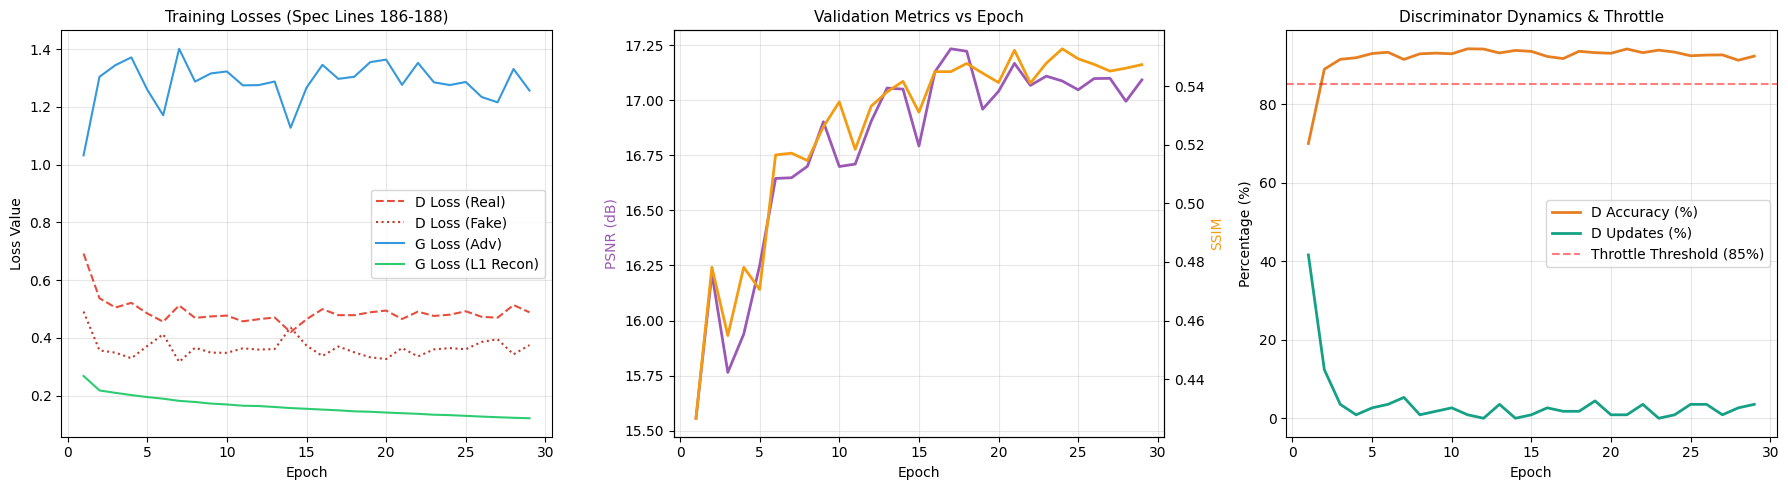

[SUCCESS] Saved training curves to artifacts/evaluation_task4/figures/training_curves.png


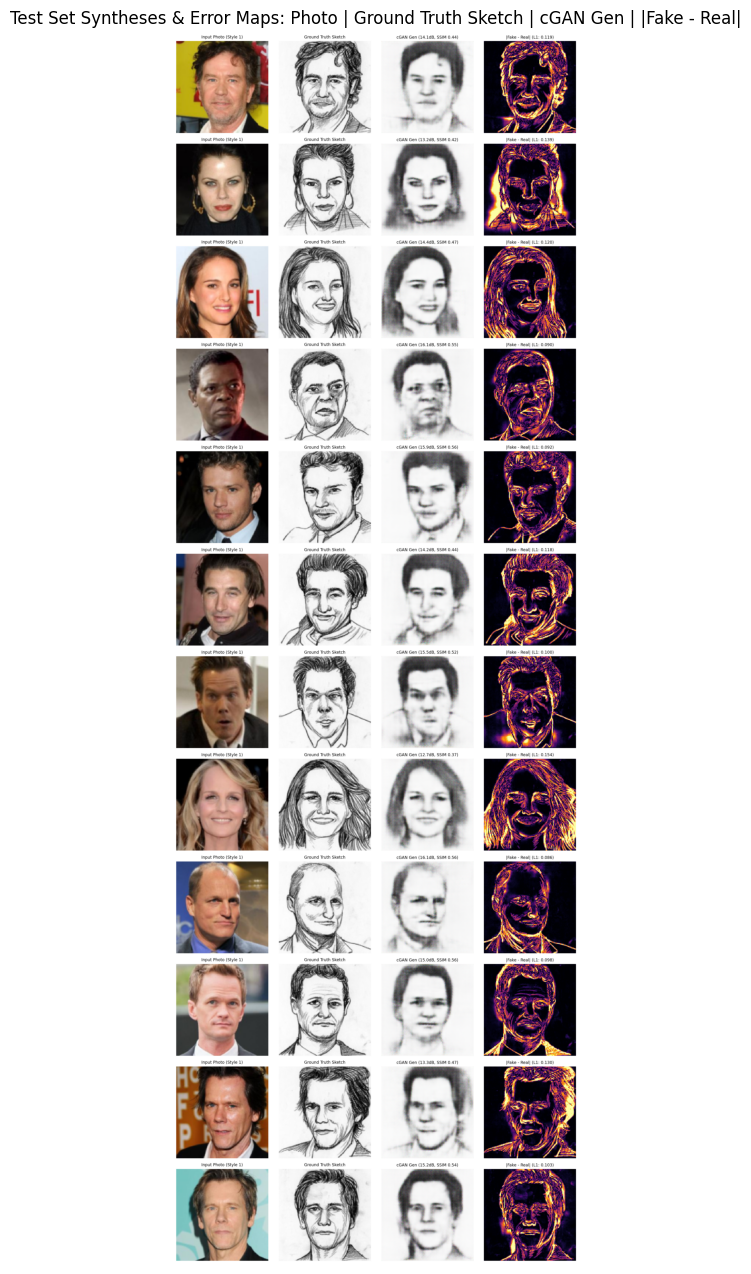

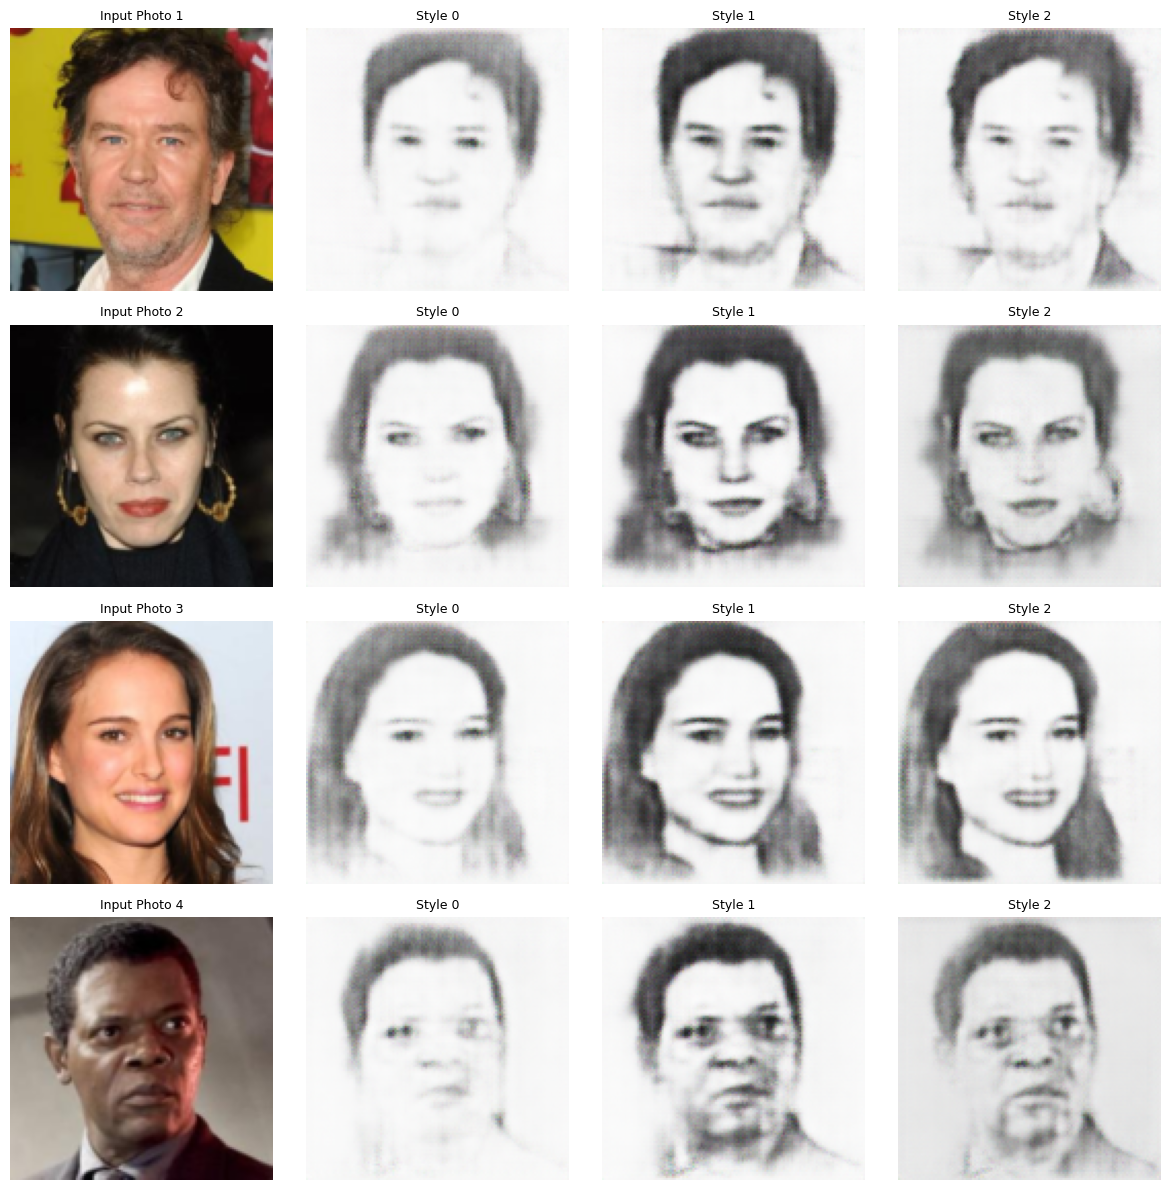

In [11]:
import os
import sys
import json
import shutil
import torch
import matplotlib.pyplot as plt
from PIL import Image

REPO_DIR = '/content/genai-restoration-studio' if os.path.exists('/content/genai-restoration-studio') else os.getcwd()
PROJECT_DIR = '/content/drive/MyDrive/GenAI-A1'
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)
os.chdir(REPO_DIR)

from models.cgan import StyleConditionedUNetGenerator
from data.fs2k import get_fs2k_dataloaders

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Re-establish test_loader and best_g if missing from memory
if 'test_loader' not in globals():
    manifest_candidates = [
        os.path.join(PROJECT_DIR, 'manifests'),
        os.path.join(PROJECT_DIR, 'configs/manifests'),
        os.path.join(REPO_DIR, 'configs/manifests'),
        os.path.join(REPO_DIR, 'manifests')
    ]
    m_dir = next(mc for mc in manifest_candidates if os.path.exists(os.path.join(mc, 'fs2k_test_manifest.json')))
    local_data = '/content/local_data/FS2K' if os.path.exists('/content/local_data/FS2K') else os.path.join(PROJECT_DIR, 'raw/FS2K/FS2K')
    _, _, test_loader = get_fs2k_dataloaders(m_dir, local_data, batch_size=16, num_workers=0)

if 'best_g' not in globals():
    optuna_candidates = [
        os.path.join(PROJECT_DIR, 'checkpoints/task4/optuna_best_params.json'),
        os.path.join(REPO_DIR, 'checkpoints/task4/optuna_best_params.json')
    ]
    p = {}
    for op in optuna_candidates:
        if os.path.exists(op):
            with open(op, 'r') as f:
                p = json.load(f)
            break
    best_g = StyleConditionedUNetGenerator(
        in_channels=3, out_channels=3, num_styles=3,
        emb_dim=int(p.get('emb_dim', 32)),
        emb_channels=16,
        base_channels=int(p.get('base_channels_g', 64)),
        dropout_rate=float(p.get('dropout_rate', 0.5))
    ).to(device)
    ckpt_candidates = [
        os.path.join(PROJECT_DIR, 'checkpoints/task4/best_cgan_generator.pth'),
        os.path.join(REPO_DIR, 'checkpoints/task4/best_cgan_generator.pth')
    ]
    target_ckpt = next(cp for cp in ckpt_candidates if os.path.exists(cp))
    ckpt = torch.load(target_ckpt, map_location=device)
    best_g.load_state_dict(ckpt['generator_state_dict'] if 'generator_state_dict' in ckpt else ckpt, strict=True)

# 1. Plot Training History Curves (GAN Losses, D Accuracy/Throttle, Val PSNR/SSIM)
history_paths = [
    'checkpoints/task4/training_history.json',
    os.path.join(PROJECT_DIR, 'checkpoints/task4/training_history.json')
]
hist_data = None
for hp in history_paths:
    if os.path.exists(hp):
        with open(hp, 'r', encoding='utf-8') as f:
            hist_data = json.load(f)
        break

if hist_data:
    epochs = [h['epoch'] for h in hist_data]
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].plot(epochs, [h['loss_d_real'] for h in hist_data], label='D Loss (Real)', color='#e74c3c', linestyle='--')
    axes[0].plot(epochs, [h['loss_d_fake'] for h in hist_data], label='D Loss (Fake)', color='#c0392b', linestyle=':')
    axes[0].plot(epochs, [h['loss_g_adv'] for h in hist_data], label='G Loss (Adv)', color='#3498db')
    axes[0].plot(epochs, [h['loss_g_recon_l1'] for h in hist_data], label='G Loss (L1 Recon)', color='#2ecc71')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss Value')
    axes[0].set_title('Training Losses (Spec Lines 186-188)', fontsize=11)
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(epochs, [h['val_psnr'] for h in hist_data], label='Val PSNR (dB)', color='#9b59b6', lw=2)
    ax1_twin = axes[1].twinx()
    ax1_twin.plot(epochs, [h['val_ssim'] for h in hist_data], label='Val SSIM', color='#f39c12', lw=2)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('PSNR (dB)', color='#9b59b6')
    ax1_twin.set_ylabel('SSIM', color='#f39c12')
    axes[1].set_title('Validation Metrics vs Epoch', fontsize=11)
    axes[1].grid(True, alpha=0.3)

    axes[2].plot(epochs, [h['d_acc_total'] * 100 for h in hist_data], label='D Accuracy (%)', color='#e67e22', lw=2)
    if 'd_updates_ratio' in hist_data[0]:
        axes[2].plot(epochs, [h['d_updates_ratio'] * 100 for h in hist_data], label='D Updates (%)', color='#16a085', lw=2)
    axes[2].axhline(85, color='red', linestyle='--', alpha=0.5, label='Throttle Threshold (85%)')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('Percentage (%)')
    axes[2].set_title('Discriminator Dynamics & Throttle', fontsize=11)
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    curves_out = 'artifacts/evaluation_task4/figures/training_curves.png'
    os.makedirs(os.path.dirname(curves_out), exist_ok=True)
    plt.savefig(curves_out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"[SUCCESS] Saved training curves to {curves_out}")

# 2. Display benchmark comparisons and error maps (|Fake - Real|)
comp_paths = [
    'artifacts/evaluation_task4/figures/test_synthesis_comparisons.png',
    os.path.join(PROJECT_DIR, 'artifacts/evaluation_task4/figures/test_synthesis_comparisons.png')
]
for cp in comp_paths:
    if os.path.exists(cp):
        plt.figure(figsize=(14, 16))
        img = Image.open(cp)
        plt.imshow(img)
        plt.axis('off')
        plt.title("Test Set Syntheses & Error Maps: Photo | Ground Truth Sketch | cGAN Gen | |Fake - Real|", fontsize=12)
        plt.show()
        break

# 3. Multi-style transfer matrix: same input photos rendered in Style 0, Style 1, Style 2
best_g.eval()
with torch.no_grad():
    sample_b = next(iter(test_loader))
    test_p = sample_b['photo'][:4].to(device)

    fig, axes = plt.subplots(4, 4, figsize=(12, 12))
    for row in range(4):
        p_np = ((test_p[row].permute(1, 2, 0).cpu().numpy() * 0.5) + 0.5).clip(0, 1)
        axes[row, 0].imshow(p_np)
        axes[row, 0].set_title(f"Input Photo {row+1}", fontsize=9)
        axes[row, 0].axis('off')

        for st_idx in range(3):
            st_t = torch.tensor([st_idx], dtype=torch.long, device=device)
            fake_st = best_g(test_p[row:row+1], st_t)
            fake_np = ((fake_st[0].permute(1, 2, 0).cpu().numpy() * 0.5) + 0.5).clip(0, 1)
            axes[row, st_idx + 1].imshow(fake_np)
            axes[row, st_idx + 1].set_title(f"Style {st_idx}", fontsize=9)
            axes[row, st_idx + 1].axis('off')

    plt.tight_layout()
    matrix_out = 'artifacts/evaluation_task4/figures/multistyle_transfer_matrix.png'
    os.makedirs(os.path.dirname(matrix_out), exist_ok=True)
    plt.savefig(matrix_out, dpi=150, bbox_inches='tight')
    plt.show()

    # Sync to Drive
    drive_fig_dir = os.path.join(PROJECT_DIR, 'artifacts/evaluation_task4/figures')
    os.makedirs(drive_fig_dir, exist_ok=True)
    shutil.copy2(matrix_out, os.path.join(drive_fig_dir, 'multistyle_transfer_matrix.png'))

### Step 9: Generator-Only ONNX Export & Parity Verification

In [12]:
import os
import sys
import json
import shutil
import torch

REPO_DIR = '/content/genai-restoration-studio' if os.path.exists('/content/genai-restoration-studio') else os.getcwd()
PROJECT_DIR = '/content/drive/MyDrive/GenAI-A1'
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)
os.chdir(REPO_DIR)

from models.cgan import StyleConditionedUNetGenerator
from models.onnx_export_cgan import export_cgan_generator_to_onnx, verify_cgan_onnx_numerical_equivalence

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

if 'best_g' not in globals():
    optuna_candidates = [
        os.path.join(PROJECT_DIR, 'checkpoints/task4/optuna_best_params.json'),
        os.path.join(REPO_DIR, 'checkpoints/task4/optuna_best_params.json')
    ]
    p = {}
    for op in optuna_candidates:
        if os.path.exists(op):
            with open(op, 'r') as f:
                p = json.load(f)
            break
    best_g = StyleConditionedUNetGenerator(
        in_channels=3, out_channels=3, num_styles=3,
        emb_dim=int(p.get('emb_dim', 32)),
        emb_channels=16,
        base_channels=int(p.get('base_channels_g', 64)),
        dropout_rate=float(p.get('dropout_rate', 0.5))
    ).to(device)
    ckpt_candidates = [
        os.path.join(PROJECT_DIR, 'checkpoints/task4/best_cgan_generator.pth'),
        os.path.join(REPO_DIR, 'checkpoints/task4/best_cgan_generator.pth')
    ]
    target_ckpt = next(cp for cp in ckpt_candidates if os.path.exists(cp))
    ckpt = torch.load(target_ckpt, map_location=device)
    best_g.load_state_dict(ckpt['generator_state_dict'] if 'generator_state_dict' in ckpt else ckpt, strict=True)

onnx_local_path = os.path.join(REPO_DIR, 'checkpoints/task4/cgan_generator.onnx')
onnx_drive_path = os.path.join(PROJECT_DIR, 'checkpoints/task4/cgan_generator.onnx')

# Export using PyTorch opset 18, dynamo=False, embedded weights
export_cgan_generator_to_onnx(best_g, onnx_local_path, opset_version=18)

# Numerical parity check with ONNX Runtime
parity_report = verify_cgan_onnx_numerical_equivalence(
    generator=best_g,
    onnx_path=onnx_local_path,
    atol=1e-4
)

assert parity_report['equivalent'] is True, "ONNX numerical parity check failed!"
assert parity_report['onnx_size_mb'] > 10.0, f"ONNX file size ({parity_report['onnx_size_mb']:.2f} MB) is suspiciously small!"

# Copy ONNX to Drive
os.makedirs(os.path.dirname(onnx_drive_path), exist_ok=True)
shutil.copy2(onnx_local_path, onnx_drive_path)

print(f"\n[ONNX SUCCESS] Standalone ONNX model exported and verified ({parity_report['onnx_size_mb']:.2f} MB).")
print(f"  Local Path: {onnx_local_path}")
print(f"  Drive Path: {onnx_drive_path}")

/usr/local/lib/python3.13/dist-packages/torch/onnx/_internal/torchscript_exporter/symbolic_opset9.py:2822: UserWarning: ONNX export mode is set to TrainingMode.EVAL, but operator 'instance_norm' is set to train=True. Exporting with train=True.
  symbolic_helper.check_training_mode(use_input_stats, "instance_norm")


[SUCCESS] cGAN Generator ONNX model verified and exported (63.63 MB, 31 weight initializers).

=== Task 4 cGAN ONNX Numerical Parity Verification ===
  PyTorch Output Shape: (3, 3, 128, 128) | Range: [-0.5210, 0.9846]
  ONNX Output Shape:    (3, 3, 128, 128) | Range: [-0.5210, 0.9846]
  Max Absolute Diff:    2.965331e-06 (Tolerance atol=0.0001)
  Mean Squared Diff:    1.186912e-13
  Parity Status:        PASS (Equivalence Confirmed)

[ONNX SUCCESS] Standalone ONNX model exported and verified (63.63 MB).
  Local Path: /content/genai-restoration-studio/checkpoints/task4/cgan_generator.onnx
  Drive Path: /content/drive/MyDrive/GenAI-A1/checkpoints/task4/cgan_generator.onnx


### Step 10: Sync All Task 4 Artifacts to Google Drive & Final Verification

In [13]:
import os
import sys
import shutil

REPO_DIR = '/content/genai-restoration-studio' if os.path.exists('/content/genai-restoration-studio') else os.getcwd()
PROJECT_DIR = '/content/drive/MyDrive/GenAI-A1'

DRIVE_CKPT_DIR = os.path.join(PROJECT_DIR, 'checkpoints/task4')
DRIVE_EVAL_DIR = os.path.join(PROJECT_DIR, 'artifacts/evaluation_task4')

os.makedirs(DRIVE_CKPT_DIR, exist_ok=True)
os.makedirs(DRIVE_EVAL_DIR, exist_ok=True)

# Copy checkpoints, ONNX, and Optuna params
local_ckpt_dir = os.path.join(REPO_DIR, 'checkpoints/task4')
if os.path.exists(local_ckpt_dir):
    for root, dirs, files in os.walk(local_ckpt_dir):
        rel = os.path.relpath(root, local_ckpt_dir)
        dest_root = os.path.join(DRIVE_CKPT_DIR, rel) if rel != '.' else DRIVE_CKPT_DIR
        os.makedirs(dest_root, exist_ok=True)
        for f in files:
            shutil.copy2(os.path.join(root, f), os.path.join(dest_root, f))

# Copy evaluation JSON and figures
local_eval_dir = os.path.join(REPO_DIR, 'artifacts/evaluation_task4')
if os.path.exists(local_eval_dir):
    for root, dirs, files in os.walk(local_eval_dir):
        rel = os.path.relpath(root, local_eval_dir)
        dest_root = os.path.join(DRIVE_EVAL_DIR, rel) if rel != '.' else DRIVE_EVAL_DIR
        os.makedirs(dest_root, exist_ok=True)
        for f in files:
            shutil.copy2(os.path.join(root, f), os.path.join(dest_root, f))

print("\n" + "=" * 60)
print("GOOGLE DRIVE TASK 4 ARTIFACT VERIFICATION")
print("=" * 60)

print(f"\nCheckpoints in {DRIVE_CKPT_DIR}:")
for f in sorted(os.listdir(DRIVE_CKPT_DIR)):
    fp = os.path.join(DRIVE_CKPT_DIR, f)
    if os.path.isfile(fp):
        size_mb = os.path.getsize(fp) / (1024 * 1024)
        print(f"  - {f} ({size_mb:.2f} MB)")
    else:
        print(f"  - [DIR] {f}/")

print(f"\nEvaluation Artifacts in {DRIVE_EVAL_DIR}:")
for root, dirs, files in os.walk(DRIVE_EVAL_DIR):
    rel = os.path.relpath(root, DRIVE_EVAL_DIR)
    for f in sorted(files):
        fp = os.path.join(root, f)
        size_mb = os.path.getsize(fp) / (1024 * 1024)
        print(f"  - {os.path.join(rel, f) if rel != '.' else f} ({size_mb:.2f} MB)")

# Assert critical files exist on Drive
assert os.path.exists(os.path.join(DRIVE_CKPT_DIR, 'best_cgan_generator.pth')), "Missing best_cgan_generator.pth on Drive!"
assert os.path.exists(os.path.join(DRIVE_CKPT_DIR, 'cgan_generator.onnx')), "Missing cgan_generator.onnx on Drive!"
assert os.path.exists(os.path.join(DRIVE_EVAL_DIR, 'cgan_benchmark_results.json')), "Missing cgan_benchmark_results.json on Drive!"

print("\n[SUCCESS] Milestone 4 complete! All artifacts securely persisted on Google Drive.")


GOOGLE DRIVE TASK 4 ARTIFACT VERIFICATION

Checkpoints in /content/drive/MyDrive/GenAI-A1/checkpoints/task4:
  - best_cgan_generator.pth (222.81 MB)
  - cgan_generator.onnx (63.63 MB)
  - optuna_best_params.json (0.00 MB)
  - [DIR] samples/
  - training_history.csv (0.00 MB)
  - training_history.json (0.01 MB)

Evaluation Artifacts in /content/drive/MyDrive/GenAI-A1/artifacts/evaluation_task4:
  - cgan_benchmark_results.json (0.00 MB)
  - figures/multistyle_transfer_matrix.png (0.72 MB)
  - figures/test_synthesis_comparisons.png (2.42 MB)
  - figures/training_curves.png (0.19 MB)

[SUCCESS] Milestone 4 complete! All artifacts securely persisted on Google Drive.
